![Gradient Descent](https://i.pinimg.com/1200x/c1/98/d7/c198d702782eb13dfc95ffe497ae68cd.jpg)

# Gradient Descent

The core problem in machine learning is that every machine learning has **parameters** (weights, biases). Every model has a **loss function** (how wrong it is). So our goal is simple:

> **Find the parameter values that make the loss as small as possible**
>

**Gradient descent** is a method for unconstrained [mathematical optimization](https://en.wikipedia.org/wiki/Mathematical_optimization). It is a [first-order iterative algorithm](https://en.wikipedia.org/wiki/Algorithm) for minimizing a [differentiable multivariate function](https://en.wikipedia.org/wiki/Function_(mathematics)#Multivariate_functions)


![Gradient Descent](https://i.pinimg.com/736x/e8/c3/74/e8c3744701c8ef7b836684ae66bc0596.jpg)

---

The idea is to take repeated steps in the opposite direction of the gradient(or approximate gradient) of the function at the current point, because this is the direction of steepest descent. Conversely, stepping in the direction of the gradient will lead to a trajectory that maximizes that function; the procedure is then known as *gradient ascent*. Gradient descent should not be confused with [local search](https://en.wikipedia.org/wiki/Local_search_(optimization)) algorithms, although both are [iterative methods](https://en.wikipedia.org/wiki/Iterative_method) for [optimization](https://en.wikipedia.org/wiki/Global_optimization)

Gradient descent is particularly useful in machine learning and artificial intelligence for minimizing the cost or loss function

---

## Essential Terms

- **Parameter**: A value the model learns (e.g., weight `w`, bias `b`)
- **Gradient ($\nabla J$)**: Measures how bad the model is. Lower = better
- **Learning Rate ($\alpha$)**: Controls step size
- **Epoch**: One full pass through the training data
- **Convergence**: When updates become tiny - we've (mostly) arrived

---

### The Gradient-What is It Really

For a function of one variable $f(x)$, the gradient is just the **derivative** $f'(x)$: the slope
- $f'(x) > 0$ &rarr; function is increasing &rarr; go **left** (substract)
- $f'(x) < 0$ &rarr; function is decreasing &rarr; go **right** (add)
- $f'(x) = 0$ &rarr; you're at a flat point (candidate minimum)

For many variables, the gradient $\nabla j$ is a **vector of partial derivatives**:
$$\nabla j(\theta) = \left[\frac{\delta j}{\delta \theta_1}, \frac{\delta j}{\delta \theta_2} \dots \frac{\delta j}{\delta \theta_n} \right ]$$

It points in the direction of **steepest increase**, so we move in the **opposite** direction

---

#### The Algorithm
$$\theta_{new} = \theta_{old} - \alpha \times \nabla J(\theta_{old})$$

"New parameters = old parameters - (learning x gradient at the old point)"

**Step-by-step Procedure**
1. Initialize $\theta$ (randomly or zeros)
2. Compute the gradient $\nabla J(\theta)$ (slope) at current $\theta$
3. Update: $\theta$ &larr; $\theta - \alpha \times \nabla J(\theta)$
4. Repeat until convergence (gradient $\approx$ 0 or max iterations reached)

---

# Practice - From Scracth

> A Gradient Descent on &rarr; $J(\theta) = \theta^2$

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
def J(theta):
    return 2*theta

def grad_J(theta):
    return 2*theta


In [29]:
# Hyperparameters
alpha = 0.1
theta = 100.0
history = [theta]

In [30]:
epoch = 25

for i in range(epoch):
    theta = theta - (alpha*grad_J(theta))
    history.append(theta)

In [31]:
print(f'Final theta: {theta}')

Final theta: 0.37778931862957166


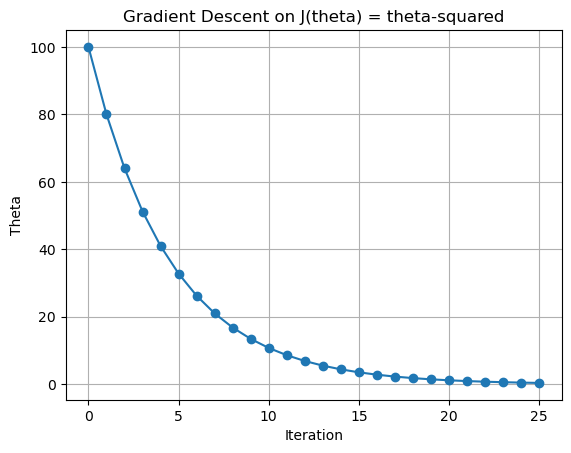

In [32]:
plt.plot(history, marker = 'o')
plt.xlabel('Iteration')
plt.ylabel('Theta')
plt.title('Gradient Descent on J(theta) = theta-squared')
plt.grid(True)

plt.show()

> Linear Regression From Scracth &rarr; $J(w,b) = (\frac{1}{n}) \sum(\hat{y_i} - y_i)^2$ $-$ MSE

In [125]:
from sklearn.datasets import make_regression

X,y = make_regression(n_samples = 4, n_features = 1, n_informative = 1, n_targets = 1, noise = 80, random_state =13)
X

array([[-0.71239066],
       [ 0.45181234],
       [-0.04450308],
       [ 0.75376638]])

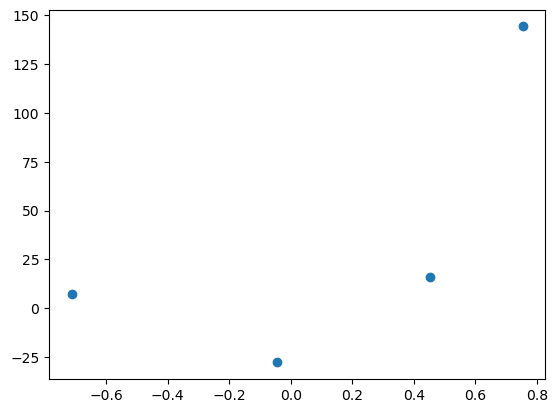

In [126]:
plt.scatter(X,y)
plt.show()

In [127]:
# Applying OLS Linear Regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [128]:
model.intercept_

np.float64(26.15963284313262)

In [129]:
model.coef_

array([78.35063668])

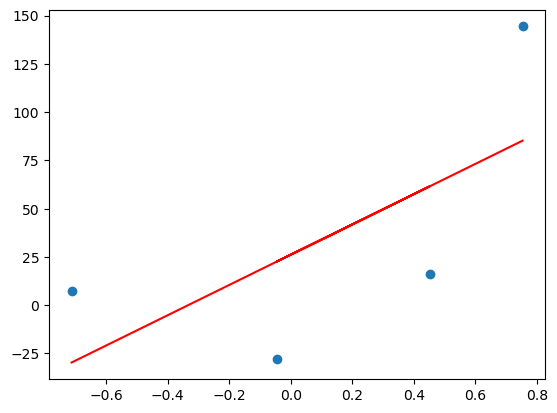

In [130]:
plt.scatter(X,y)
plt.plot(X, model.predict(X), color = 'red')

plt.show()

### Applying Gradient Descent
> Assume slope(m) = 78.35, b = 0

In [136]:
m = 78.35
b0 = 0

In [137]:
y_pred = ((m*X) + b0).reshape(4)

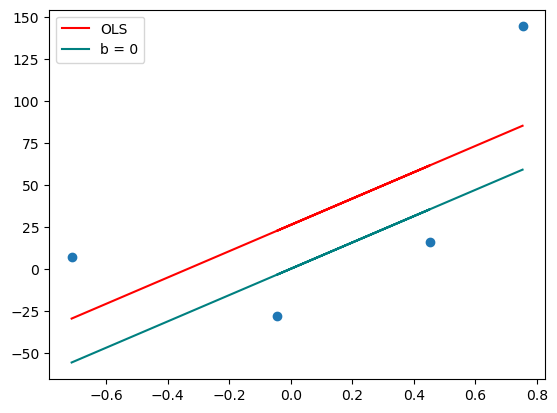

In [138]:
plt.scatter(X,y)
plt.plot(X,model.predict(X), color = 'red', label = 'OLS')
plt.plot(X,y_pred, color = 'teal', label = 'b = 0')
plt.legend()

plt.show()

In [139]:
loss_slope = -2 * (np.sum(y - m*X.ravel()) - b)
loss_slope

np.float64(-209.27763408209216)

In [140]:
alpha = 0.1
step_size = alpha * loss_slope
step_size

np.float64(-20.927763408209216)

In [141]:
# Calculate new b
b1 = b0 -  step_size
b1

np.float64(20.927763408209216)

In [142]:
y_pred1 = ((m*X) + b1).reshape(4)

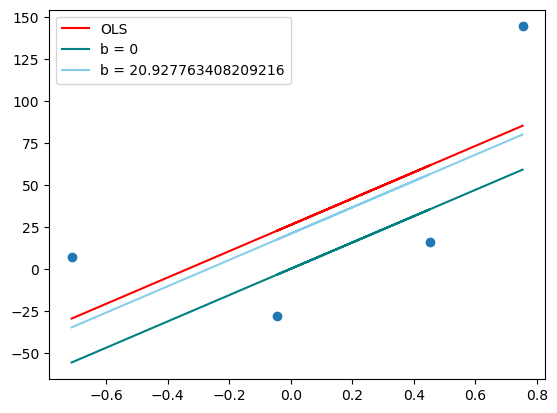

In [144]:
plt.scatter(X,y)
plt.plot(X, model.predict(X), color = 'red', label = 'OLS')
plt.plot(X, y_pred, color = 'teal', label = 'b = 0')
plt.plot(X, y_pred1, color = 'skyblue', label = f'b = {b1}')
plt.legend()

plt.show()

In [145]:
loss_slope = -2 * (np.sum(y - m*X.ravel() - b1))
loss_slope

np.float64(-41.85552681641843)

In [146]:
step_size = alpha * loss_slope
step_size

np.float64(-4.185552681641844)

In [147]:
b2 = b1 - step_size
b2

np.float64(25.11331608985106)

In [148]:
y_pred2 = (m*X + b2).reshape(4)

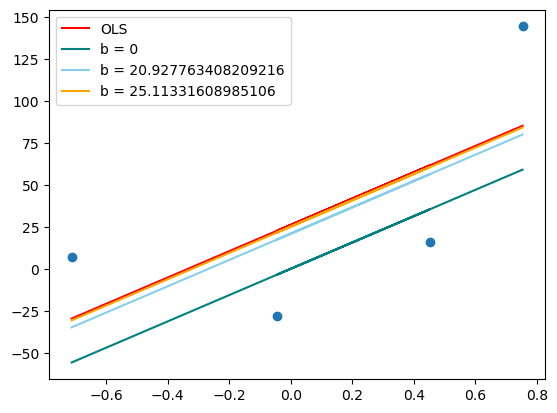

In [150]:
plt.scatter(X,y)
plt.plot(X, model.predict(X), color = 'red', label = 'OLS')
plt.plot(X, y_pred, color = 'teal', label = 'b = 0')
plt.plot(X, y_pred1, color = 'skyblue', label = f'b = {b1}')
plt.plot(X, y_pred2, color = 'orange', label = f'b = {b2}')
plt.legend()

plt.show()

In [153]:
loss_slope = -2 * (np.sum(y - m*X.ravel() - b2))
loss_slope

np.float64(-8.371105363283675)

In [154]:
step_size = alpha * loss_slope
step_size

np.float64(-0.8371105363283675)

In [155]:
b3 = b2 - step_size
b3

np.float64(25.95042662617943)

In [156]:
y_pred3 = (m*X + b3).reshape(4)

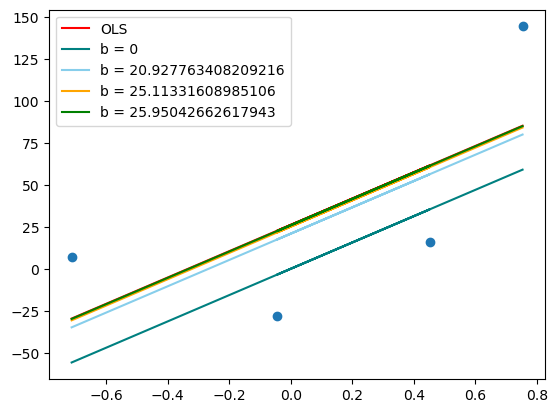

In [158]:
plt.scatter(X,y)
plt.plot(X, model.predict(X), color = 'red', label = 'OLS')
plt.plot(X, y_pred, color = 'teal', label = 'b = 0')
plt.plot(X, y_pred1, color = 'skyblue', label = f'b = {b1}')
plt.plot(X, y_pred2, color = 'orange', label = f'b = {b2}')
plt.plot(X, y_pred3, color = 'green', label = f'b = {b3}')
plt.legend()

plt.show()

In [159]:
loss_slope = -2 * (np.sum(y - m*X.ravel() - b3))
loss_slope

np.float64(-1.674221072656735)

In [160]:
step_size = alpha * loss_slope
step_size

np.float64(-0.16742210726567353)

In [161]:
b4 = b3 - step_size
b4

np.float64(26.1178487334451)

In [162]:
y_pred4 = (m*X + b4).reshape(4)

In [171]:
(m*X + b4)

array([[-29.69795964],
       [ 61.51734547],
       [ 22.63103255],
       [ 85.1754445 ]])

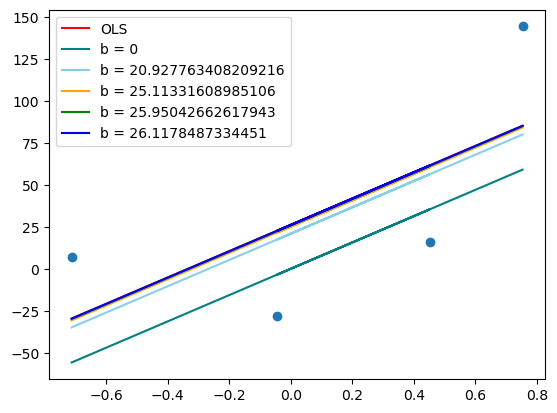

In [164]:
plt.scatter(X,y)
plt.plot(X, model.predict(X), color = 'red', label = 'OLS')
plt.plot(X, y_pred, color = 'teal', label = 'b = 0')
plt.plot(X, y_pred1, color = 'skyblue', label = f'b = {b1}')
plt.plot(X, y_pred2, color = 'orange', label = f'b = {b2}')
plt.plot(X, y_pred3, color = 'green', label = f'b = {b3}')
plt.plot(X, y_pred4, color = 'blue', label = f'b = {b4}')
plt.legend()

plt.show()

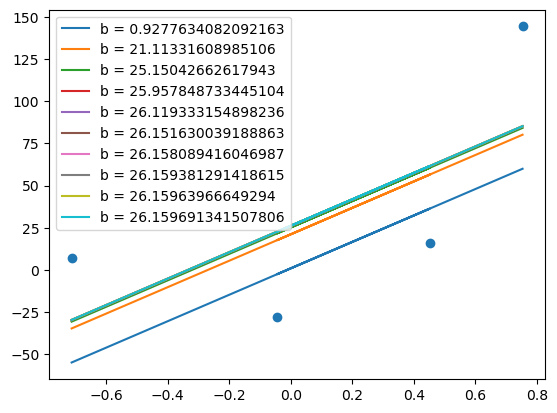

In [188]:
b = -100
m = 78.35
alpha = 0.1

epoch = 10

for i in range(epoch):
    loss_slope = -2 * (np.sum(y - m*X.ravel() - b))
    step_size = alpha*loss_slope
    b = b - step_size

    y_pred = m*X + b

    plt.plot(X, y_pred, label = f'b = {b}')
    plt.legend()
plt.scatter(X,y)